# Custom Point-Wise Interventions: Causal vs Traditional Models

This notebook evaluates causal vs traditional ML models using **200 individual point-wise interventions**, each at a single random time step with a diverse random intervention value.

**Key difference from `004_ts_benchmark.ipynb`:** Instead of shifting an entire variable globally, each intervention is applied at a single random row with a randomly sampled value from diverse strategies (uniform, normal, extreme, zero, sign flip, constant shift).

**Evaluation Protocol:**
- **Ground Truth**: Recompute target using the true SCM equation + original noise
- **Traditional Model**: Replace all X1 lags with intervention value, keep everything else unchanged, predict directly
- **Causal Model**: Propagate intervention through the causal graph in topological order (`what_if=True`)

**DGP Configuration:** `n_vars=4, max_lag=2, gaussian noise`

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from pygam import LinearGAM, s
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from scipy import stats

import utils as ut

current_path = Path(__file__).resolve().parent if '__file__' in globals() else Path().resolve()
print("Setup complete.")

Setup complete.


## 1. Data Generating Process (from A2C)

We copy the core DGP functions from the A2C notebook so this notebook is self-contained.

In [2]:
# ============================================================
# DGP: Time Series Generator (from A2C.ipynb)
# ============================================================

def get_linear_equations(n_vars, max_lag):
    """Get linear equations for specified configuration with confounder"""
    if n_vars == 4:
        if max_lag == 2:
            return [
                "X4[t] = 0.25 * X1[t-2] + e4",
                "X3[t] = 0.35 * X4[t] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
        elif max_lag == 3:
            return [
                "X4[t] = 0.25 * X1[t-2] + e4",
                "X3[t] = 0.35 * X4[t] + 0.2 * X2[t-3] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
        elif max_lag == 4:
            return [
                "X4[t] = 0.25 * X1[t-4] + e4",
                "X3[t] = 0.35 * X4[t] + 0.2 * X2[t-3] + 0.3 * U[t] + e3",
                "X2[t] = 0.3 * X3[t-1] + e2",
                "X1[t] = 0.4 * X2[t] + 0.5 * U[t] + e1",
                "U[t] = eU"
            ]
    return []


def extract_causal_links(equations):
    """Extract causal links: {(source, lag, target): coefficient}"""
    causal_links = {}
    for eq in equations:
        if '=' not in eq:
            continue
        left, right = [side.strip() for side in eq.split('=')]
        target = left.split('[')[0]
        # Skip pure noise equations (e.g., "U[t] = eU") 
        if right.startswith('e'):
            continue
        terms = [term.strip() for term in right.replace('- ', '+ -').split('+')]
        for term in terms:
            term = term.strip()
            if '*' in term:
                coeff, var_part = [p.strip() for p in term.split('*')]
                var = var_part.split('[')[0]
                if var.startswith('e'):
                    continue
                lag_part = var_part.split('[')[1].split(']')[0]
                lag = 0 if lag_part == 't' else int(lag_part.split('-')[1])
                causal_links[(var, lag, target)] = float(coeff)
    return causal_links


class TimeSeriesGenerator:
    def __init__(self, noise_scale=0.1, random_state=None):
        self.noise_scale = noise_scale
        self.random_state = random_state

    def generate_noise(self, size):
        return np.random.normal(0, self.noise_scale, size=size)

    def generate(self, n_points, n_vars, max_lag):
        """Generate multivariate time series from the SCM."""
        if self.random_state is not None:
            np.random.seed(self.random_state)

        equations = get_linear_equations(n_vars, max_lag)
        causal_links = extract_causal_links(equations)

        X = np.zeros((n_points, n_vars))
        U = np.zeros(n_points)

        # Initialize with noise
        for i in range(max_lag):
            X[i] = self.generate_noise(n_vars)
            U[i] = self.generate_noise(1)[0]

        # Generate time series step by step
        for t in range(max_lag, n_points):
            noise = self.generate_noise(n_vars + 1)
            U[t] = noise[-1]  # Confounder is pure noise

            for i in range(n_vars):
                var_name = f'X{i+1}'
                value = 0
                has_parents = False
                for (source, lag, target), coef in causal_links.items():
                    if target == var_name:
                        has_parents = True
                        if source == 'U':
                            value += coef * U[t]
                        else:
                            source_idx = int(source[1:]) - 1
                            value += coef * X[t - lag, source_idx]
                if has_parents:
                    X[t, i] = value + noise[i]
                else:
                    X[t, i] = noise[i]  # Exogenous variable

        columns = [f'X{i+1}' for i in range(n_vars)] + ['U']
        df = pd.DataFrame(np.column_stack([X, U]), columns=columns)
        return df

print("DGP functions defined.")

DGP functions defined.


## 2. Configuration & Data Generation

In [3]:
# ============================================================
# Configuration
# ============================================================
N_POINTS = 1000
N_VARS = 4
MAX_LAG = 2
TRAIN_RATIO = 0.8
RANDOM_STATE = 42
TARGET_VAR = 'X4'  # deepest downstream variable
INTERVENE_VAR = 'X1'  # variable to intervene on
N_INTERVENTIONS = 200  # number of point-wise interventions

# Generate data
generator = TimeSeriesGenerator(noise_scale=0.1, random_state=RANDOM_STATE)
df_full = generator.generate(n_points=N_POINTS, n_vars=N_VARS, max_lag=MAX_LAG)

print(f"Generated time series: {df_full.shape}")
print(f"Columns: {list(df_full.columns)}")
print(f"\nFirst 5 rows:")
df_full.head()

Generated time series: (1000, 5)
Columns: ['X1', 'X2', 'X3', 'X4', 'U']

First 5 rows:


,X1,X2,X3,X4,U
0,0.049671,-0.013826,0.064769,0.152303,-0.023415
1,-0.023414,0.157921,0.076743,-0.046947,0.054256
2,-0.132588,-0.023550,-0.027551,-0.178910,-0.172492
3,-0.126844,-0.109549,-0.010944,-0.096656,-0.141230
4,0.119346,-0.025861,-0.009579,-0.175622,-0.054438


## 3. Feature Engineering: Lagged Features

In [4]:
def create_lagged_features(df, max_lag, var_columns):
    """
    Create lagged feature columns for each variable.
    
    For each variable Xi, creates Xi_lag1, Xi_lag2, ..., Xi_lagK.
    Also keeps the contemporaneous values (lag 0) as Xi_lag0.
    Drops rows with NaNs from lagging.
    """
    df_lagged = pd.DataFrame(index=df.index)
    
    for col in var_columns:
        # Contemporaneous value (lag 0)
        df_lagged[f'{col}_lag0'] = df[col]
        # Lagged values
        for lag in range(1, max_lag + 1):
            df_lagged[f'{col}_lag{lag}'] = df[col].shift(lag)
    
    # Drop rows with NaNs (first max_lag rows)
    df_lagged = df_lagged.dropna().reset_index(drop=True)
    return df_lagged


# All variables including U
all_vars = [f'X{i+1}' for i in range(N_VARS)] + ['U']

# Create lagged features
df_lagged = create_lagged_features(df_full, MAX_LAG, all_vars)

print(f"Lagged dataset shape: {df_lagged.shape}")
print(f"Columns: {list(df_lagged.columns)}")
df_lagged.head()

Lagged dataset shape: (998, 15)
Columns: ['X1_lag0', 'X1_lag1', 'X1_lag2', 'X2_lag0', 'X2_lag1', 'X2_lag2', 'X3_lag0', 'X3_lag1', 'X3_lag2', 'X4_lag0', 'X4_lag1', 'X4_lag2', 'U_lag0', 'U_lag1', 'U_lag2']


,X1_lag0,X1_lag1,X1_lag2,X2_lag0,X2_lag1,X2_lag2,X3_lag0,X3_lag1,X3_lag2,X4_lag0,X4_lag1,X4_lag2,U_lag0,U_lag1,U_lag2
0,-0.132588,-0.023414,0.049671,-0.023550,0.157921,-0.013826,-0.027551,0.076743,0.064769,-0.178910,-0.046947,0.152303,-0.172492,0.054256,-0.023415
1,-0.126844,-0.132588,-0.023414,-0.109549,-0.023550,0.157921,-0.010944,-0.027551,0.076743,-0.096656,-0.178910,-0.046947,-0.141230,-0.172492,0.054256
2,0.119346,-0.126844,-0.132588,-0.025861,-0.109549,-0.023550,-0.009579,-0.010944,-0.027551,-0.175622,-0.096656,-0.178910,-0.054438,-0.141230,-0.172492
3,-0.003492,0.119346,-0.126844,-0.117973,-0.025861,-0.109549,0.028819,-0.009579,-0.010944,-0.091775,-0.175622,-0.096656,-0.029169,-0.054438,-0.141230
4,-0.019043,-0.003492,0.119346,0.193874,-0.117973,-0.025861,0.023327,0.028819,-0.009579,-0.075935,-0.091775,-0.175622,0.082254,-0.029169,-0.054438


## 4. Build Causal Graph with Lagged Edges

In [5]:
def build_lagged_causal_graph(n_vars, max_lag):
    """
    Build a DAG over flattened lagged features using the known SCM equations.
    Each node is a lagged feature like 'X1_lag0', 'X3_lag1', etc.
    """
    equations = get_linear_equations(n_vars, max_lag)
    causal_links = extract_causal_links(equations)
    
    G = nx.DiGraph()
    parent_map = {}  # {target_lag0: [parent_features]}
    
    for (source, lag, target), coef in causal_links.items():
        source_feature = f'{source}_lag{lag}'
        target_feature = f'{target}_lag0'  # target is always at current time
        G.add_edge(source_feature, target_feature)
        
        if target_feature not in parent_map:
            parent_map[target_feature] = []
        parent_map[target_feature].append(source_feature)
    
    return G, parent_map


G, parent_map = build_lagged_causal_graph(N_VARS, MAX_LAG)

print("Causal Graph Edges:")
for edge in G.edges():
    print(f"  {edge[0]} → {edge[1]}")

print(f"\nParent map (features used by causal models):")
for target, parents in parent_map.items():
    print(f"  {target}: {parents}")

Causal Graph Edges:
  X1_lag2 → X4_lag0
  X4_lag0 → X3_lag0
  U_lag0 → X3_lag0
  U_lag0 → X1_lag0
  X3_lag1 → X2_lag0
  X2_lag0 → X1_lag0

Parent map (features used by causal models):
  X4_lag0: ['X1_lag2']
  X3_lag0: ['X4_lag0', 'U_lag0']
  X2_lag0: ['X3_lag1']
  X1_lag0: ['X2_lag0', 'U_lag0']


## 5. Train/Test Split (Chronological)

In [6]:
# Chronological split
split_idx = int(len(df_lagged) * TRAIN_RATIO)
train_df = df_lagged.iloc[:split_idx].reset_index(drop=True)
test_df = df_lagged.iloc[split_idx:].reset_index(drop=True)

# Also split the raw data for intervention generation later
raw_split_idx = int(len(df_full) * TRAIN_RATIO)
test_df_raw = df_full.iloc[raw_split_idx:].reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")

# Target column (contemporaneous, lag 0)
target_col = f'{TARGET_VAR}_lag0'
print(f"\nTarget column: {target_col}")

Train size: 798
Test size:  200

Target column: X4_lag0


## 5b. Visualization: Train/Test Split

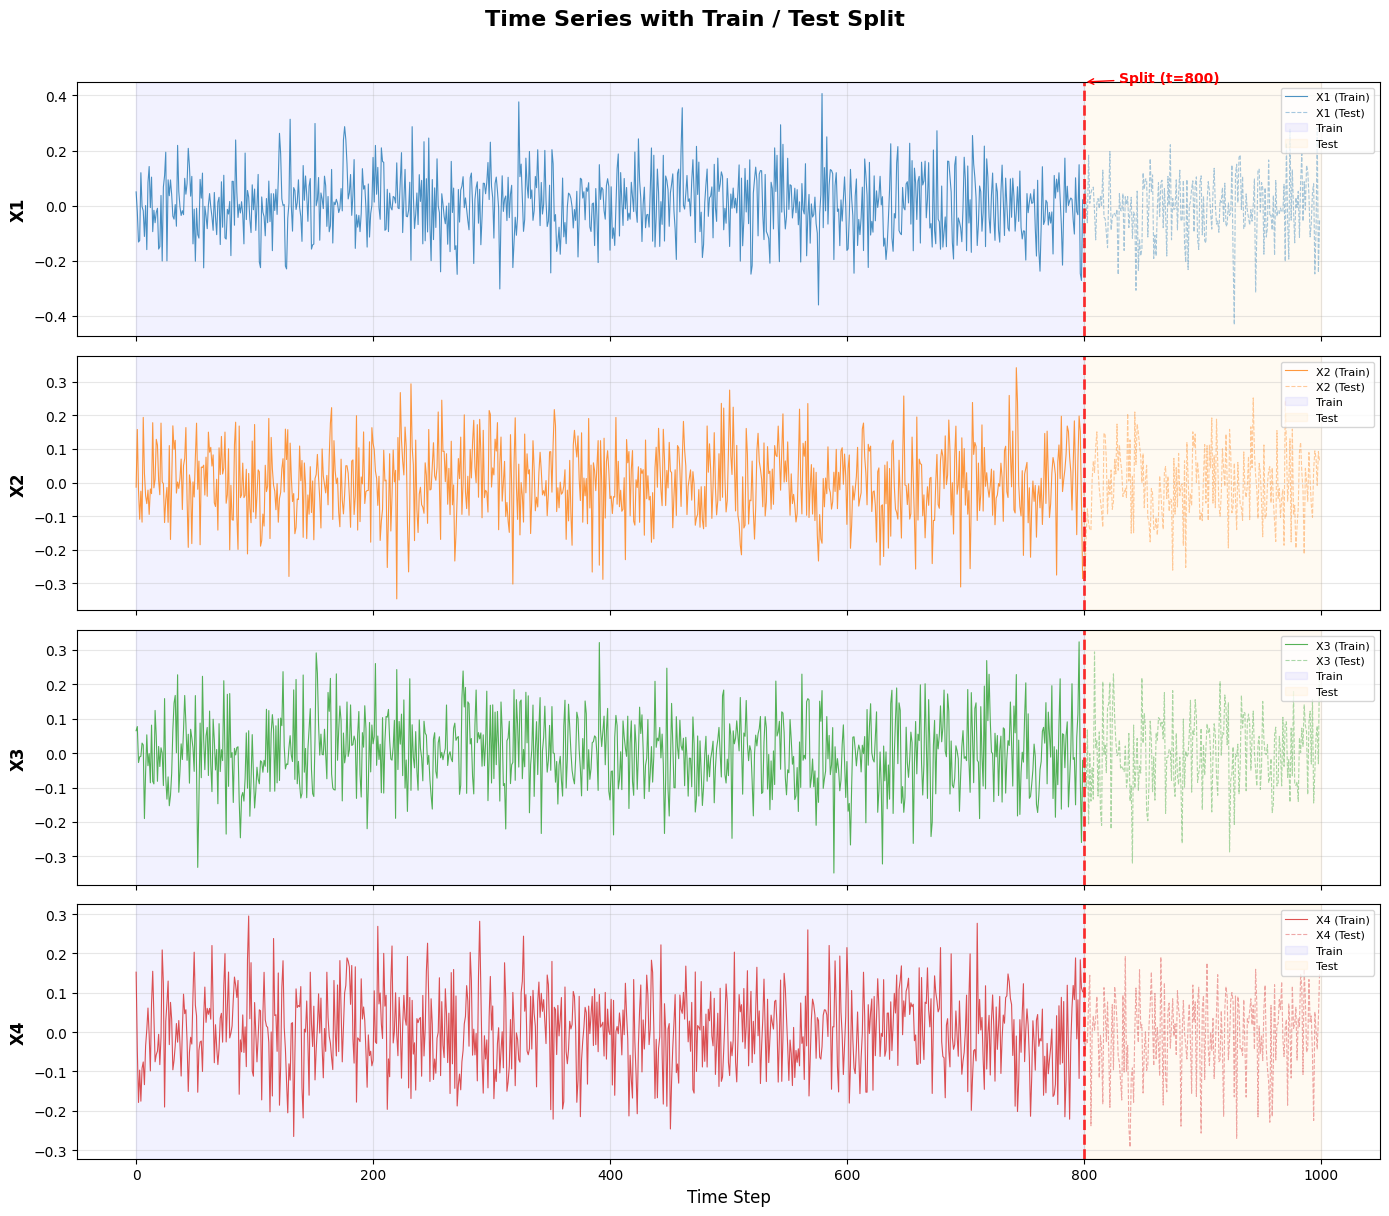


Train: t=0 to t=799 (800 points)
Test:  t=800 to t=999 (200 points)


In [7]:
fig, axes = plt.subplots(N_VARS, 1, figsize=(14, 3 * N_VARS), sharex=True)
fig.suptitle('Time Series with Train / Test Split', fontsize=16, fontweight='bold', y=1.01)

colors = plt.cm.tab10.colors
time_idx = np.arange(len(df_full))

for i in range(N_VARS):
    ax = axes[i]
    var = f'X{i+1}'
    
    ax.plot(time_idx[:raw_split_idx], df_full[var].iloc[:raw_split_idx],
            color=colors[i], alpha=0.8, linewidth=0.8, label=f'{var} (Train)')
    ax.plot(time_idx[raw_split_idx:], df_full[var].iloc[raw_split_idx:],
            color=colors[i], alpha=0.4, linewidth=0.8, linestyle='--', label=f'{var} (Test)')
    ax.axvline(x=raw_split_idx, color='red', linestyle='--', linewidth=2, alpha=0.8)
    ax.axvspan(0, raw_split_idx, alpha=0.05, color='blue', label='Train')
    ax.axvspan(raw_split_idx, len(df_full), alpha=0.05, color='orange', label='Test')
    ax.set_ylabel(var, fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time Step', fontsize=12)
axes[0].annotate(f'Split (t={raw_split_idx})', xy=(raw_split_idx, axes[0].get_ylim()[1]),
                 xytext=(raw_split_idx + 30, axes[0].get_ylim()[1]),
                 fontsize=10, color='red', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

print(f"\nTrain: t=0 to t={raw_split_idx-1} ({raw_split_idx} points)")
print(f"Test:  t={raw_split_idx} to t={len(df_full)-1} ({len(df_full) - raw_split_idx} points)")

## 6. Model Definitions

In [8]:
# Models with default hyperparameters (no tuning)
model_configs = {
    "RandomForest": {
        "class": RandomForestRegressor,
        "params": {"n_estimators": 200, "max_depth": 10, "random_state": 42}
    },
    "LinearRegression": {
        "class": LinearRegression,
        "params": {}
    },
    "MLP": {
        "class": MLPRegressor,
        "params": {"hidden_layer_sizes": (100, 50), "max_iter": 1000, "random_state": 42}
    },
    "XGBoost": {
        "class": XGBRegressor,
        "params": {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1,
                   "random_state": 42, "verbosity": 0}
    },
    "GAM": {
        "class": None,  # handled separately
        "params": {}
    },
}

print(f"Models to evaluate: {list(model_configs.keys())}")

Models to evaluate: ['RandomForest', 'LinearRegression', 'MLP', 'XGBoost', 'GAM']


## 7. Training & Evaluation Functions

In [9]:
def get_traditional_features(df_lagged, target_col):
    """For traditional models: use ALL lagged features (excluding the target itself)."""
    feature_cols = [c for c in df_lagged.columns if c != target_col]
    return feature_cols


def get_causal_features(parent_map, target_col):
    """For causal models: use ONLY the parent features from the known causal graph."""
    if target_col in parent_map:
        return parent_map[target_col]
    return []


def fit_gam(X_train, y_train):
    """Fit a GAM model."""
    if isinstance(X_train, pd.DataFrame):
        X_train = X_train.values
    n_features = X_train.shape[1]
    formula = s(0)
    for i in range(1, n_features):
        formula = formula + s(i)
    model = LinearGAM(formula, max_iter=5000)
    model.fit(X_train, y_train)
    return model


def predict_gam(model, X_test):
    """Predict with a GAM model."""
    if isinstance(X_test, pd.DataFrame):
        X_test = X_test.values
    return model.predict(X_test)


def fit_model(name, cfg, X_train, y_train):
    """Fit a model given its config."""
    if name == "GAM":
        return fit_gam(X_train, y_train)
    else:
        model = cfg["class"](**cfg["params"])
        if isinstance(X_train, pd.DataFrame):
            model.fit(X_train.values, y_train.values)
        else:
            model.fit(X_train, y_train)
        return model


def predict_model(name, model, X_test):
    """Predict with a model."""
    if name == "GAM":
        return predict_gam(model, X_test)
    else:
        if isinstance(X_test, pd.DataFrame):
            return model.predict(X_test.values)
        return model.predict(X_test)


def evaluate_metrics(y_true, y_pred):
    """Compute MAE, RMSE, WAPE."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = 100.0 * np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-10)
    return mae, rmse, wape


print("Training and evaluation functions defined.")

Training and evaluation functions defined.


## 8. Causal Model Training (Per-Node)

For the **causal** approach, we train a separate model for each node (variable at lag 0) that has parents in the causal graph.

In [10]:
def train_causal_models_ts(train_df, parent_map, model_name, model_cfg):
    """
    Train one model per node in the causal graph.
    Each model predicts a node from its known causal parents.
    """
    causal_models = {}
    for node, parents in parent_map.items():
        if not parents:
            continue
        X = train_df[parents]
        y = train_df[node]
        model = fit_model(model_name, model_cfg, X, y)
        causal_models[node] = model
    return causal_models


def predict_causal_ts(df, parent_map, causal_models, model_name, what_if=False):
    """
    Predict using causal models.
    
    If what_if=False: use observed parent values (test evaluation).
    If what_if=True: propagate predictions forward through the graph 
                     (intervention evaluation - use predicted upstream values).
    """
    preds = pd.DataFrame(index=df.index)
    
    if what_if:
        working_df = df.copy()
        predicted_nodes = set()
        remaining = dict(parent_map)
        
        max_iter = len(remaining) + 1
        for _ in range(max_iter):
            if not remaining:
                break
            for node, parents in list(remaining.items()):
                lag0_parents = [p for p in parents if p.endswith('_lag0')]
                lag0_parents_predicted = all(
                    p in predicted_nodes or p not in parent_map 
                    for p in lag0_parents
                )
                
                if lag0_parents_predicted:
                    X_pred = working_df[parents]
                    model = causal_models[node]
                    prediction = predict_model(model_name, model, X_pred)
                    preds[node] = prediction
                    working_df[node] = prediction  # Update for downstream nodes
                    predicted_nodes.add(node)
                    del remaining[node]
    else:
        for node, parents in parent_map.items():
            if node in causal_models:
                X_pred = df[parents]
                model = causal_models[node]
                preds[node] = predict_model(model_name, model, X_pred)
    
    return preds


print("Causal model training functions defined.")

Causal model training functions defined.


## 9. Observational Evaluation

Train all models and evaluate on the test set (standard forecasting accuracy).

In [11]:
obs_results = []

# Traditional feature set: all features except the target
trad_features = get_traditional_features(df_lagged, target_col)

# Causal feature set: only parents of the target
causal_features = get_causal_features(parent_map, target_col)

print(f"Target: {target_col}")
print(f"Traditional features ({len(trad_features)}): {trad_features}")
print(f"Causal features ({len(causal_features)}):     {causal_features}")
print()

# Store all trained models for later use in the intervention loop
all_causal_models = {}  # {model_name: {node: model}}
all_trad_models = {}    # {model_name: model}

for name, cfg in model_configs.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    
    # ---- CAUSAL MODEL ----
    causal_models = train_causal_models_ts(train_df, parent_map, name, cfg)
    all_causal_models[name] = causal_models
    
    # Test evaluation (causal)
    causal_preds = predict_causal_ts(test_df, parent_map, causal_models, name, what_if=False)
    if target_col in causal_preds.columns:
        mae_c, rmse_c, wape_c = evaluate_metrics(test_df[target_col], causal_preds[target_col])
        obs_results.append(["Causal", name, mae_c, rmse_c, wape_c])
        print(f"  Causal Test  - MAE: {mae_c:.4f}, RMSE: {rmse_c:.4f}, WAPE: {wape_c:.2f}%")
    
    # ---- TRADITIONAL MODEL ----
    X_train_trad = train_df[trad_features]
    y_train = train_df[target_col]
    trad_model = fit_model(name, cfg, X_train_trad, y_train)
    all_trad_models[name] = trad_model
    
    # Test evaluation (traditional)
    X_test_trad = test_df[trad_features]
    y_pred_trad = predict_model(name, trad_model, X_test_trad)
    mae_t, rmse_t, wape_t = evaluate_metrics(test_df[target_col], y_pred_trad)
    obs_results.append(["Traditional", name, mae_t, rmse_t, wape_t])
    print(f"  Trad   Test  - MAE: {mae_t:.4f}, RMSE: {rmse_t:.4f}, WAPE: {wape_t:.2f}%")

# Display observational results
obs_results_df = pd.DataFrame(
    obs_results, columns=["Model_Type", "Algorithm", "MAE", "RMSE", "WAPE"]
).sort_values("MAE").reset_index(drop=True)

print("\n" + "="*60)
print("OBSERVATIONAL TEST SET PERFORMANCE")
print("="*60)
obs_results_df

Target: X4_lag0
Traditional features (14): ['X1_lag0', 'X1_lag1', 'X1_lag2', 'X2_lag0', 'X2_lag1', 'X2_lag2', 'X3_lag0', 'X3_lag1', 'X3_lag2', 'X4_lag1', 'X4_lag2', 'U_lag0', 'U_lag1', 'U_lag2']
Causal features (1):     ['X1_lag2']


Training: RandomForest
  Causal Test  - MAE: 0.0823, RMSE: 0.1037, WAPE: 101.41%
  Trad   Test  - MAE: 0.0772, RMSE: 0.0987, WAPE: 95.12%

Training: LinearRegression
  Causal Test  - MAE: 0.0775, RMSE: 0.0976, WAPE: 95.39%
  Trad   Test  - MAE: 0.0792, RMSE: 0.0993, WAPE: 97.52%

Training: MLP
  Causal Test  - MAE: 0.0776, RMSE: 0.0978, WAPE: 95.50%
  Trad   Test  - MAE: 0.0787, RMSE: 0.0986, WAPE: 96.88%

Training: XGBoost
  Causal Test  - MAE: 0.0879, RMSE: 0.1092, WAPE: 108.30%
  Trad   Test  - MAE: 0.0805, RMSE: 0.1038, WAPE: 99.13%

Training: GAM
  Causal Test  - MAE: 0.0773, RMSE: 0.0981, WAPE: 95.23%
  Trad   Test  - MAE: 0.0870, RMSE: 0.1116, WAPE: 107.09%

OBSERVATIONAL TEST SET PERFORMANCE


,Model_Type,Algorithm,MAE,RMSE,WAPE
0,Traditional,RandomForest,0.077246,0.098689,95.123761
1,Causal,GAM,0.077330,0.098111,95.227036
2,Causal,LinearRegression,0.077461,0.097648,95.387677
3,Causal,MLP,0.077550,0.097759,95.498000
4,Traditional,MLP,0.078671,0.098588,96.878327
5,Traditional,LinearRegression,0.079190,0.099277,97.517696
6,Traditional,XGBoost,0.080503,0.103752,99.133636
7,Causal,RandomForest,0.082348,0.103661,101.406008
8,Traditional,GAM,0.086966,0.111624,107.092413
9,Causal,XGBoost,0.087945,0.109239,108.298198


## 10. Custom Point-Wise Intervention Loop

For each of the **200 interventions**, we:
1. Sample a random intervention value from diverse strategies (uniform, normal, extreme, zero, sign flip, constant shift)
2. Pick a random row from the test set
3. Compute ground truth using the true SCM: `X4_true = 0.25 * v + original_noise`
4. **Traditional model**: Replace ALL X1 lags with intervention value `v`, keep all other features unchanged, predict X4 directly
5. **Causal model**: Set X1_lag2 = `v` in the row, propagate through graph in topological order (`what_if=True`)
6. Record per-intervention results

In [12]:
def sample_intervention_value(rng, x1_mean, x1_std):
    """
    Sample an intervention value from diverse strategies.
    Returns (value, strategy_label).
    """
    strategy = rng.choice([
        'uniform', 'normal', 'extreme_high', 'extreme_low',
        'zero', 'sign_flip', 'constant_shift_pos', 'constant_shift_neg'
    ])
    
    if strategy == 'uniform':
        v = rng.uniform(x1_mean - 3 * x1_std, x1_mean + 3 * x1_std)
    elif strategy == 'normal':
        v = rng.normal(x1_mean, x1_std)
    elif strategy == 'extreme_high':
        v = x1_mean + rng.uniform(3, 5) * x1_std
    elif strategy == 'extreme_low':
        v = x1_mean - rng.uniform(3, 5) * x1_std
    elif strategy == 'zero':
        v = 0.0
    elif strategy == 'sign_flip':
        v = -x1_mean
    elif strategy == 'constant_shift_pos':
        v = x1_mean + 2 * x1_std
    elif strategy == 'constant_shift_neg':
        v = x1_mean - 2 * x1_std
    
    return v, strategy


def compute_ground_truth_pointwise(row, intervention_value, causal_links, target_var='X4'):
    """
    Compute ground truth for a single point-wise do(X1 = v) intervention.
    
    For the SCM: X4[t] = 0.25 * X1[t-2] + e4
    Ground truth = 0.25 * v + original_noise
    where original_noise = observed_X4 - 0.25 * original_X1_lag2
    """
    # Extract the coefficient and lag for X1 -> X4
    coef = None
    source_lag_col = None
    for (source, lag, target), c in causal_links.items():
        if target == target_var and source == 'X1':
            coef = c
            source_lag_col = f'X1_lag{lag}'
            break
    
    # Original structural component
    original_structural = coef * row[source_lag_col]
    # Original noise = observed - structural
    original_noise = row[f'{target_var}_lag0'] - original_structural
    # Ground truth under intervention
    ground_truth = coef * intervention_value + original_noise
    
    return ground_truth


def evaluate_traditional_pointwise(row, intervention_value, trad_model, model_name, 
                                    trad_features, intervene_var='X1', max_lag=2):
    """
    Traditional model evaluation for a single point-wise intervention.
    Replace ALL X1 lags with the intervention value, keep everything else unchanged.
    """
    row_modified = row[trad_features].copy()
    
    # Replace all lags of the intervened variable
    for lag in range(max_lag + 1):
        col = f'{intervene_var}_lag{lag}'
        if col in row_modified.index:
            row_modified[col] = intervention_value
    
    # Predict from the single modified row
    X_input = pd.DataFrame([row_modified])
    pred = predict_model(model_name, trad_model, X_input)
    return pred[0]


def evaluate_causal_pointwise(row, intervention_value, causal_models, model_name,
                               parent_map, G, intervene_var='X1', max_lag=2):
    """
    Causal model evaluation for a single point-wise intervention.
    Set X1_lag2 = v (the relevant lag for X4), then propagate through the graph.
    """
    # Create a single-row DataFrame with the intervention applied
    row_df = pd.DataFrame([row])
    
    # Apply intervention: set the specific lag that appears in the SCM
    # For X4[t] = 0.25 * X1[t-2], we set X1_lag2 = v
    for lag in range(max_lag + 1):
        col = f'{intervene_var}_lag{lag}'
        if col in row_df.columns:
            row_df[col] = intervention_value
    
    # Propagate through the causal graph using what_if=True
    causal_preds = predict_causal_ts(row_df, parent_map, causal_models, model_name, what_if=True)
    
    target_col = f'{TARGET_VAR}_lag0'
    if target_col in causal_preds.columns:
        return causal_preds[target_col].values[0]
    return np.nan


print("Point-wise intervention functions defined.")

Point-wise intervention functions defined.


In [13]:
# ============================================================
# Run 200 Point-Wise Interventions
# ============================================================
equations = get_linear_equations(N_VARS, MAX_LAG)
causal_links = extract_causal_links(equations)

x1_mean = df_full[INTERVENE_VAR].mean()
x1_std = df_full[INTERVENE_VAR].std()

rng = np.random.RandomState(RANDOM_STATE)
intervention_records = []

print(f"Running {N_INTERVENTIONS} point-wise interventions on {INTERVENE_VAR}...")
print(f"  {INTERVENE_VAR} stats: μ={x1_mean:.4f}, σ={x1_std:.4f}")
print(f"  Models: {list(model_configs.keys())}")
print()

for i in range(N_INTERVENTIONS):
    # 1. Sample intervention value
    v, strategy = sample_intervention_value(rng, x1_mean, x1_std)
    
    # 2. Pick a random row from the test set
    row_idx = rng.randint(0, len(test_df))
    row = test_df.iloc[row_idx]
    
    # 3. Compute ground truth
    gt = compute_ground_truth_pointwise(row, v, causal_links, TARGET_VAR)
    
    # 4 & 5. Evaluate each model (traditional and causal)
    for model_name in model_configs.keys():
        trad_model = all_trad_models[model_name]
        causal_models = all_causal_models[model_name]
        
        # Traditional prediction
        trad_pred = evaluate_traditional_pointwise(
            row, v, trad_model, model_name, trad_features, INTERVENE_VAR, MAX_LAG
        )
        
        # Causal prediction
        causal_pred = evaluate_causal_pointwise(
            row, v, causal_models, model_name, parent_map, G, INTERVENE_VAR, MAX_LAG
        )
        
        # 6. Record results
        intervention_records.append({
            'intervention_id': i,
            'row_idx': row_idx,
            'intervention_value': v,
            'strategy': strategy,
            'delta': v - row[f'{INTERVENE_VAR}_lag0'],
            'algorithm': model_name,
            'ground_truth': gt,
            'traditional_pred': trad_pred,
            'causal_pred': causal_pred,
            'traditional_error': np.abs(gt - trad_pred),
            'causal_error': np.abs(gt - causal_pred),
        })
    
    if (i + 1) % 50 == 0:
        print(f"  Completed {i + 1}/{N_INTERVENTIONS} interventions")

# Create results DataFrame
interv_df = pd.DataFrame(intervention_records)

print(f"\nDone! {len(interv_df)} records ({N_INTERVENTIONS} interventions × {len(model_configs)} models)")
interv_df.head(10)

Running 200 point-wise interventions on X1...
  X1 stats: μ=0.0018, σ=0.1121
  Models: ['RandomForest', 'LinearRegression', 'MLP', 'XGBoost', 'GAM']

  Completed 50/200 interventions
  Completed 100/200 interventions
  Completed 150/200 interventions
  Completed 200/200 interventions

Done! 1000 records (200 interventions × 5 models)


,intervention_id,row_idx,intervention_value,strategy,delta,algorithm,ground_truth,traditional_pred,causal_pred,traditional_error,causal_error
0,0,179,0.226006,constant_shift_pos,0.196801,RandomForest,0.123593,0.089364,0.062955,0.034229,0.060638
1,0,179,0.226006,constant_shift_pos,0.196801,LinearRegression,0.123593,0.061334,0.056438,0.062259,0.067155
2,0,179,0.226006,constant_shift_pos,0.196801,MLP,0.123593,0.082105,0.055686,0.041487,0.067907
3,0,179,0.226006,constant_shift_pos,0.196801,XGBoost,0.123593,0.144647,0.045666,0.021055,0.077927
4,0,179,0.226006,constant_shift_pos,0.196801,GAM,0.123593,0.123911,0.076501,0.000318,0.047092
5,1,14,0.000000,zero,-0.034903,RandomForest,-0.014490,0.007179,0.030047,0.021669,0.044538
6,1,14,0.000000,zero,-0.034903,LinearRegression,-0.014490,0.005902,0.002134,0.020393,0.016625
7,1,14,0.000000,zero,-0.034903,MLP,-0.014490,-0.004688,0.002480,0.009802,0.016970
8,1,14,0.000000,zero,-0.034903,XGBoost,-0.014490,-0.027867,0.048075,0.013376,0.062565
9,1,14,0.000000,zero,-0.034903,GAM,-0.014490,-0.004609,0.002065,0.009882,0.016556


## 11. Aggregation: RMSE / MAE / WAPE Across All 200 Interventions

Compute aggregate metrics for each model and model type across all point-wise interventions.

In [14]:
# ============================================================
# Aggregate metrics per model
# ============================================================
agg_results = []

for model_name in model_configs.keys():
    model_df = interv_df[interv_df['algorithm'] == model_name]
    gt = model_df['ground_truth'].values
    
    # Traditional
    trad_preds = model_df['traditional_pred'].values
    trad_mae, trad_rmse, trad_wape = evaluate_metrics(gt, trad_preds)
    agg_results.append({
        'Model_Type': 'Traditional',
        'Algorithm': model_name,
        'MAE': trad_mae,
        'RMSE': trad_rmse,
        'WAPE': trad_wape,
    })
    
    # Causal
    causal_preds = model_df['causal_pred'].values
    causal_mae, causal_rmse, causal_wape = evaluate_metrics(gt, causal_preds)
    agg_results.append({
        'Model_Type': 'Causal',
        'Algorithm': model_name,
        'MAE': causal_mae,
        'RMSE': causal_rmse,
        'WAPE': causal_wape,
    })

agg_df = pd.DataFrame(agg_results).sort_values(['Algorithm', 'Model_Type']).reset_index(drop=True)

print("=" * 80)
print(f"INTERVENTION PERFORMANCE: {N_INTERVENTIONS} Point-Wise Interventions on {INTERVENE_VAR}")
print(f"Config: n_vars={N_VARS}, max_lag={MAX_LAG}, target={TARGET_VAR}")
print("=" * 80)
agg_df

INTERVENTION PERFORMANCE: 200 Point-Wise Interventions on X1
Config: n_vars=4, max_lag=2, target=X4


,Model_Type,Algorithm,MAE,RMSE,WAPE
0,Causal,GAM,0.078195,0.098634,81.394521
1,Traditional,GAM,0.120807,0.154067,125.750724
2,Causal,LinearRegression,0.077886,0.096304,81.073131
3,Traditional,LinearRegression,0.081280,0.100765,84.606173
4,Causal,MLP,0.077902,0.096753,81.089310
5,Traditional,MLP,0.080590,0.097902,83.887688
6,Causal,RandomForest,0.083934,0.104029,87.368132
7,Traditional,RandomForest,0.084499,0.106769,87.956903
8,Causal,XGBoost,0.088700,0.108313,92.329543
9,Traditional,XGBoost,0.088296,0.111200,91.908695


In [15]:
# ============================================================
# Summary pivot: Causal vs Traditional MAE per algorithm
# ============================================================
pivot_mae = agg_df.pivot(index='Algorithm', columns='Model_Type', values='MAE')
pivot_mae['Causal_Improvement_%'] = (
    (pivot_mae['Traditional'] - pivot_mae['Causal']) / pivot_mae['Traditional'] * 100
)

print("\n" + "=" * 70)
print("MAE COMPARISON: Causal vs Traditional (per algorithm)")
print("=" * 70)
print(pivot_mae.to_string())
print("\nPositive improvement % means causal outperforms traditional.")

# Breakdown by intervention strategy
print("\n" + "=" * 70)
print("MAE BY INTERVENTION STRATEGY")
print("=" * 70)
strategy_summary = interv_df.groupby('strategy').agg(
    n=('intervention_id', 'nunique'),
    mean_trad_error=('traditional_error', 'mean'),
    mean_causal_error=('causal_error', 'mean'),
).reset_index()
strategy_summary['causal_improvement_%'] = (
    (strategy_summary['mean_trad_error'] - strategy_summary['mean_causal_error']) 
    / strategy_summary['mean_trad_error'] * 100
)
print(strategy_summary.to_string(index=False))


MAE COMPARISON: Causal vs Traditional (per algorithm)
Model_Type          Causal  Traditional  Causal_Improvement_%
Algorithm                                                    
GAM               0.078195     0.120807             35.273120
LinearRegression  0.077886     0.081280              4.175868
MLP               0.077902     0.080590              3.335863
RandomForest      0.083934     0.084499              0.669386
XGBoost           0.088700     0.088296             -0.457897

Positive improvement % means causal outperforms traditional.

MAE BY INTERVENTION STRATEGY
          strategy  n  mean_trad_error  mean_causal_error  causal_improvement_%
constant_shift_neg 33         0.098981           0.089727              9.348619
constant_shift_pos 28         0.078470           0.079412             -1.199831
      extreme_high 23         0.089736           0.064714             27.883846
       extreme_low 24         0.124045           0.081657             34.171322
            normal 

## 12. Visualizations

### 12a. Scatter Plots: Predicted vs Ground Truth (per model)

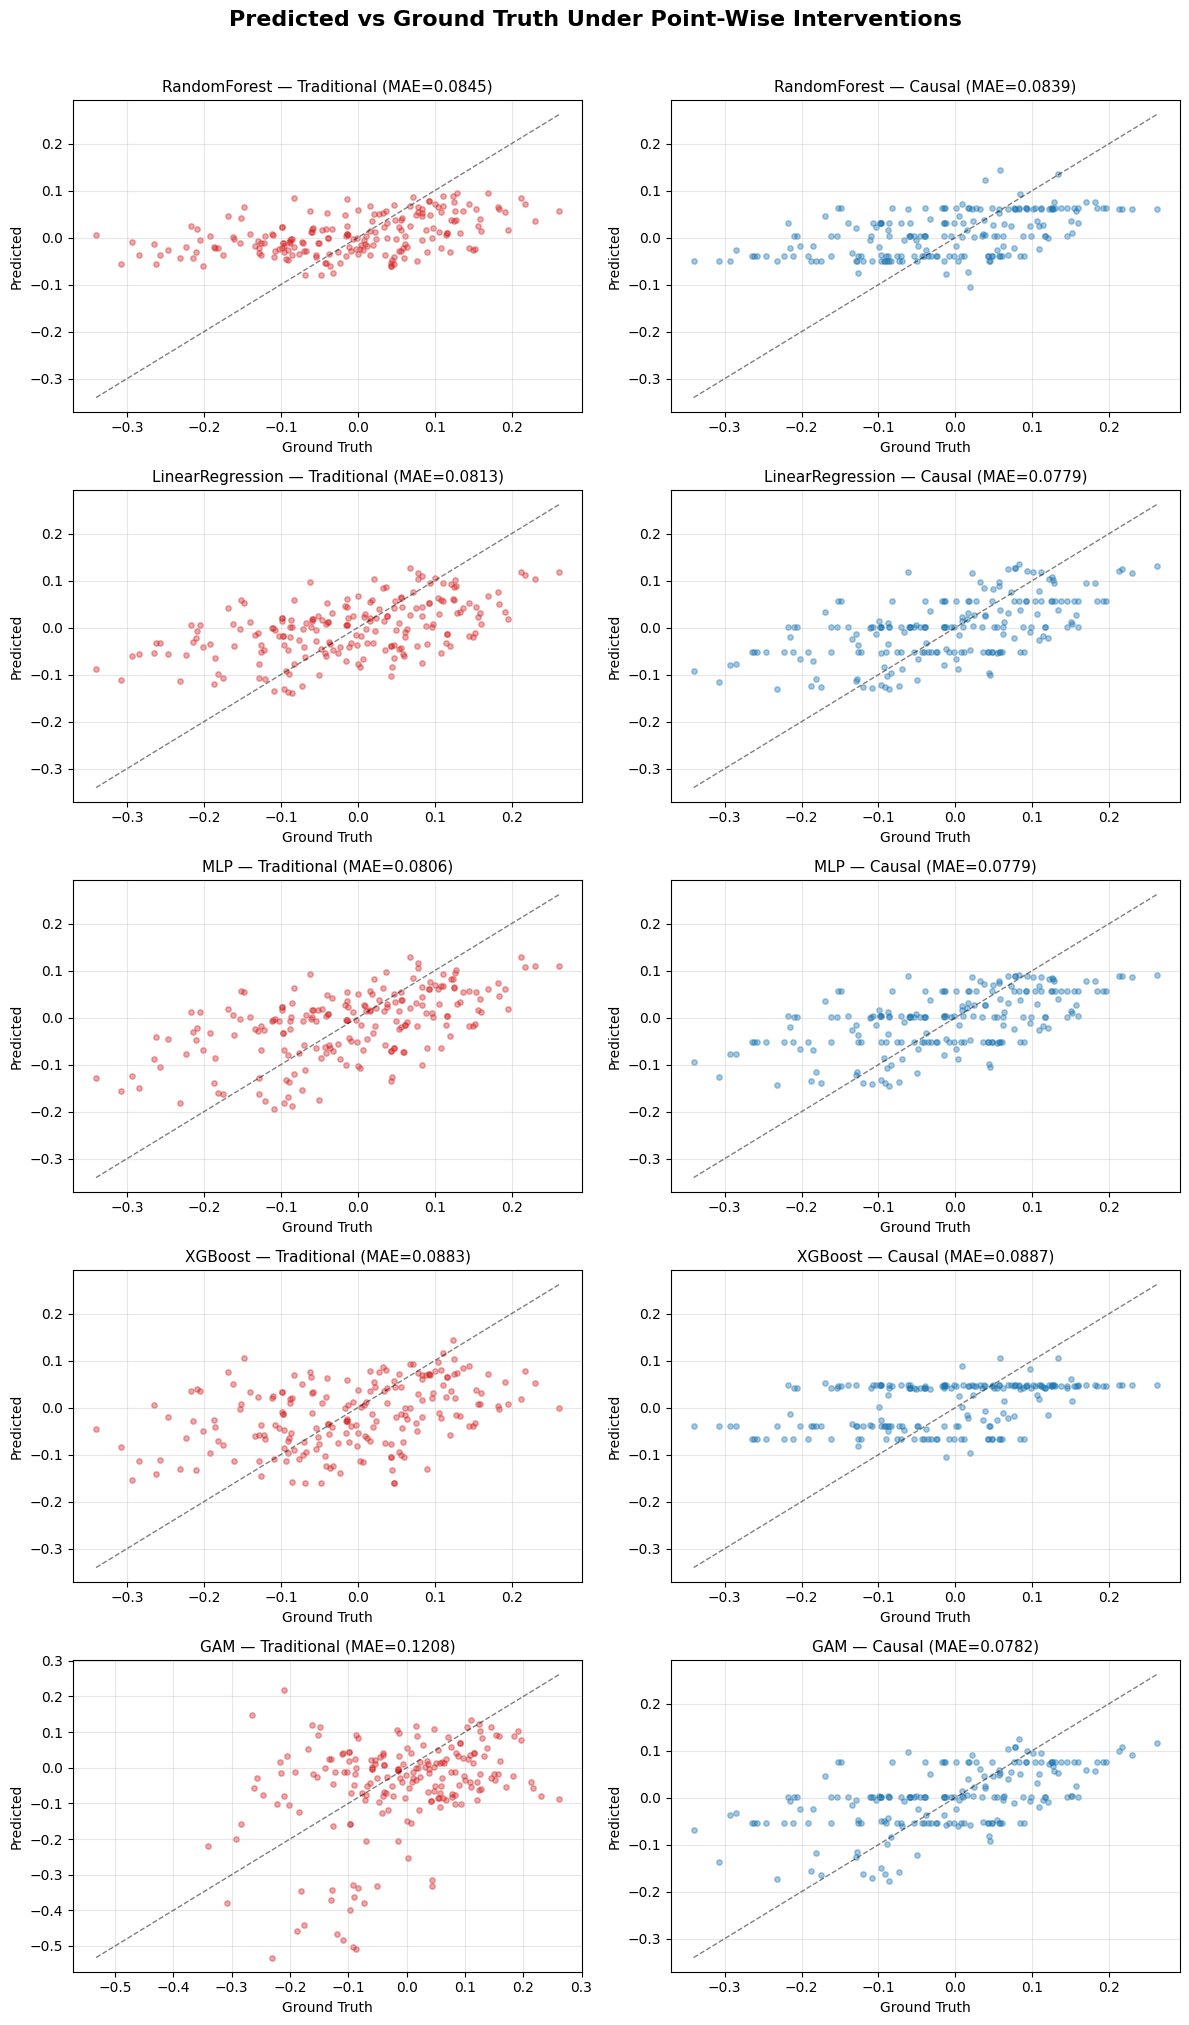

In [16]:
# ============================================================
# Scatter: Predicted vs Ground Truth (Causal vs Traditional)
# ============================================================
model_names = list(model_configs.keys())
n_models = len(model_names)

fig, axes = plt.subplots(n_models, 2, figsize=(12, 4 * n_models), squeeze=False)
fig.suptitle('Predicted vs Ground Truth Under Point-Wise Interventions',
             fontsize=16, fontweight='bold', y=1.01)

for i, model_name in enumerate(model_names):
    model_df = interv_df[interv_df['algorithm'] == model_name]
    gt = model_df['ground_truth'].values
    
    # Traditional
    ax = axes[i, 0]
    trad_preds = model_df['traditional_pred'].values
    ax.scatter(gt, trad_preds, alpha=0.4, s=15, color='tab:red')
    lims = [min(gt.min(), trad_preds.min()), max(gt.max(), trad_preds.max())]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1)
    mae_t = np.mean(np.abs(gt - trad_preds))
    ax.set_title(f'{model_name} — Traditional (MAE={mae_t:.4f})', fontsize=11)
    ax.set_xlabel('Ground Truth')
    ax.set_ylabel('Predicted')
    ax.grid(True, alpha=0.3)
    
    # Causal
    ax = axes[i, 1]
    causal_preds = model_df['causal_pred'].values
    ax.scatter(gt, causal_preds, alpha=0.4, s=15, color='tab:blue')
    lims = [min(gt.min(), causal_preds.min()), max(gt.max(), causal_preds.max())]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1)
    mae_c = np.mean(np.abs(gt - causal_preds))
    ax.set_title(f'{model_name} — Causal (MAE={mae_c:.4f})', fontsize=11)
    ax.set_xlabel('Ground Truth')
    ax.set_ylabel('Predicted')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 12b. Error Distribution: Causal vs Traditional

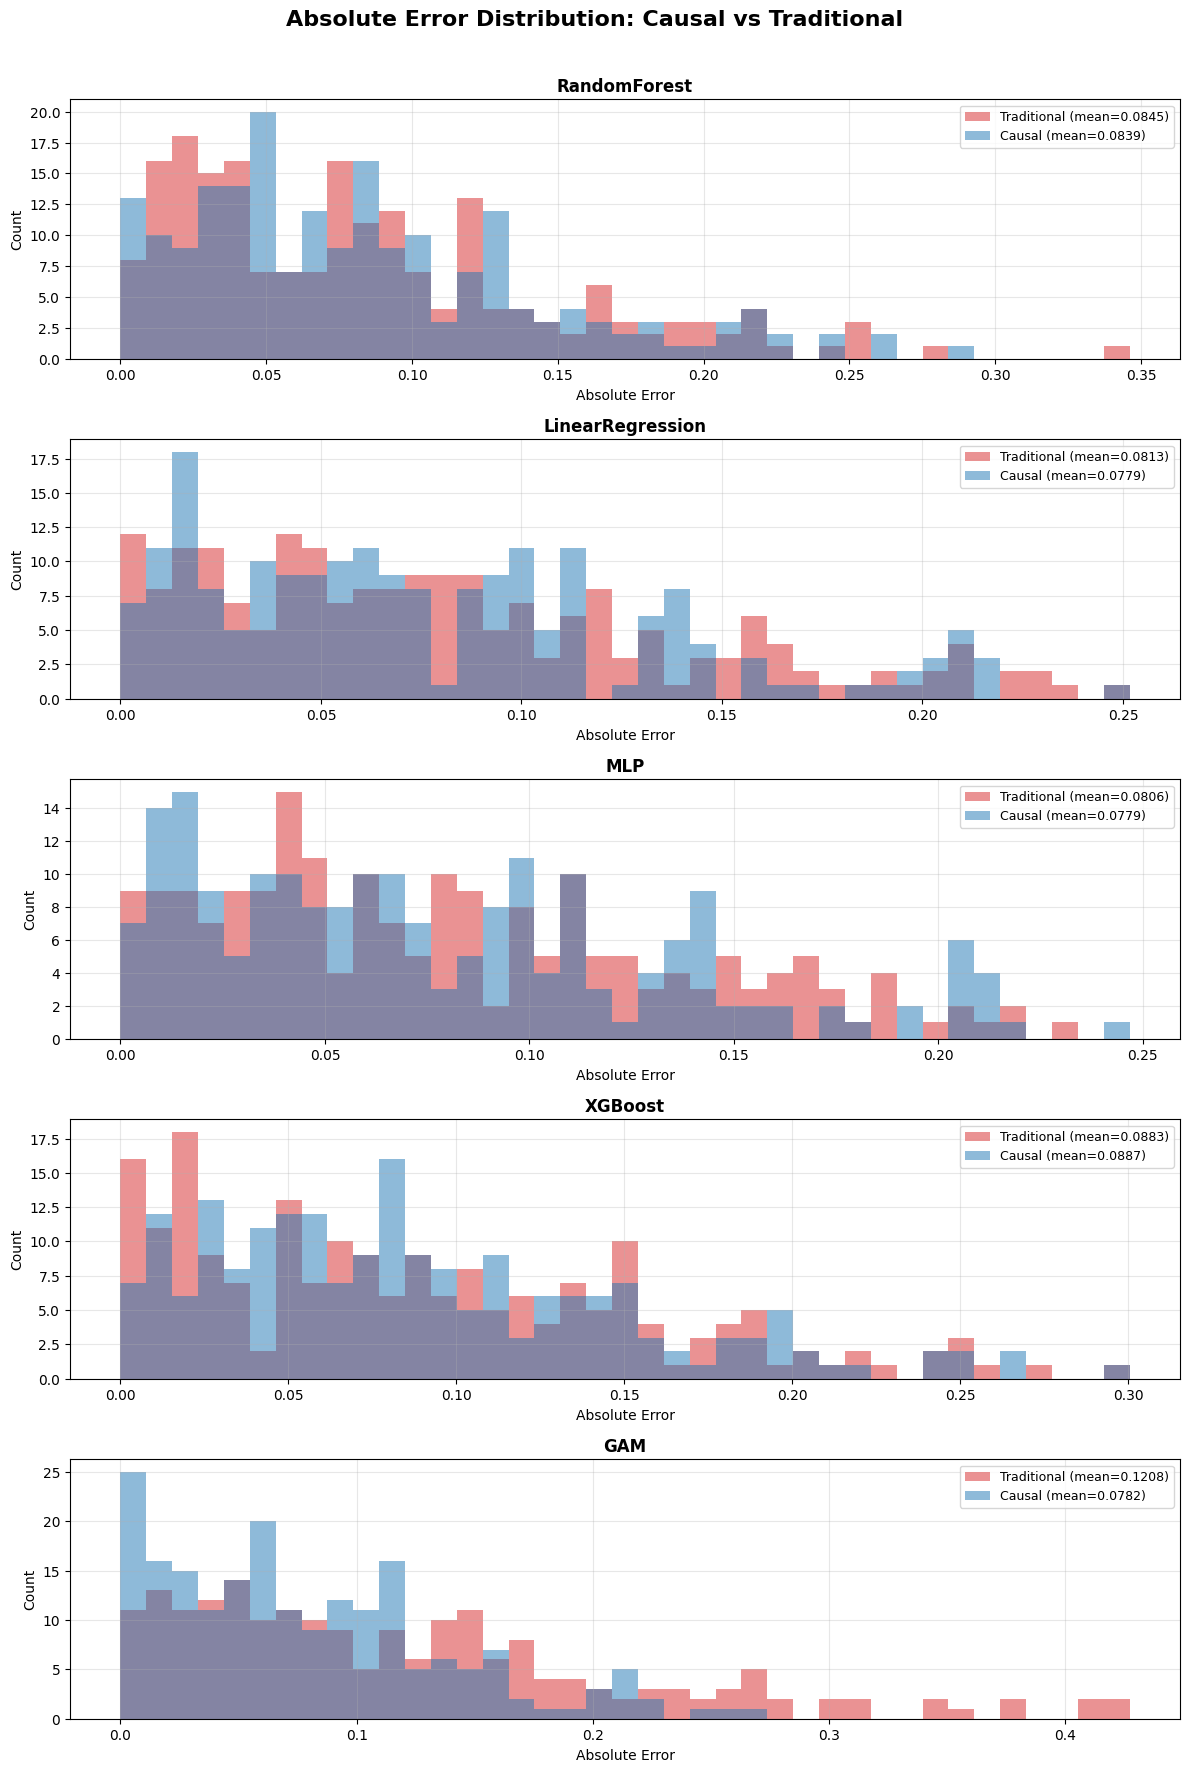

In [17]:
# ============================================================
# Error Distribution Histograms
# ============================================================
fig, axes = plt.subplots(n_models, 1, figsize=(12, 3.5 * n_models), squeeze=False)
fig.suptitle('Absolute Error Distribution: Causal vs Traditional',
             fontsize=16, fontweight='bold', y=1.01)

for i, model_name in enumerate(model_names):
    ax = axes[i, 0]
    model_df = interv_df[interv_df['algorithm'] == model_name]
    
    bins = np.linspace(0, max(model_df['traditional_error'].max(), model_df['causal_error'].max()), 40)
    
    ax.hist(model_df['traditional_error'], bins=bins, alpha=0.5, color='tab:red',
            label=f'Traditional (mean={model_df["traditional_error"].mean():.4f})')
    ax.hist(model_df['causal_error'], bins=bins, alpha=0.5, color='tab:blue',
            label=f'Causal (mean={model_df["causal_error"].mean():.4f})')
    
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Absolute Error')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 12c. Error Breakdown by Intervention Strategy

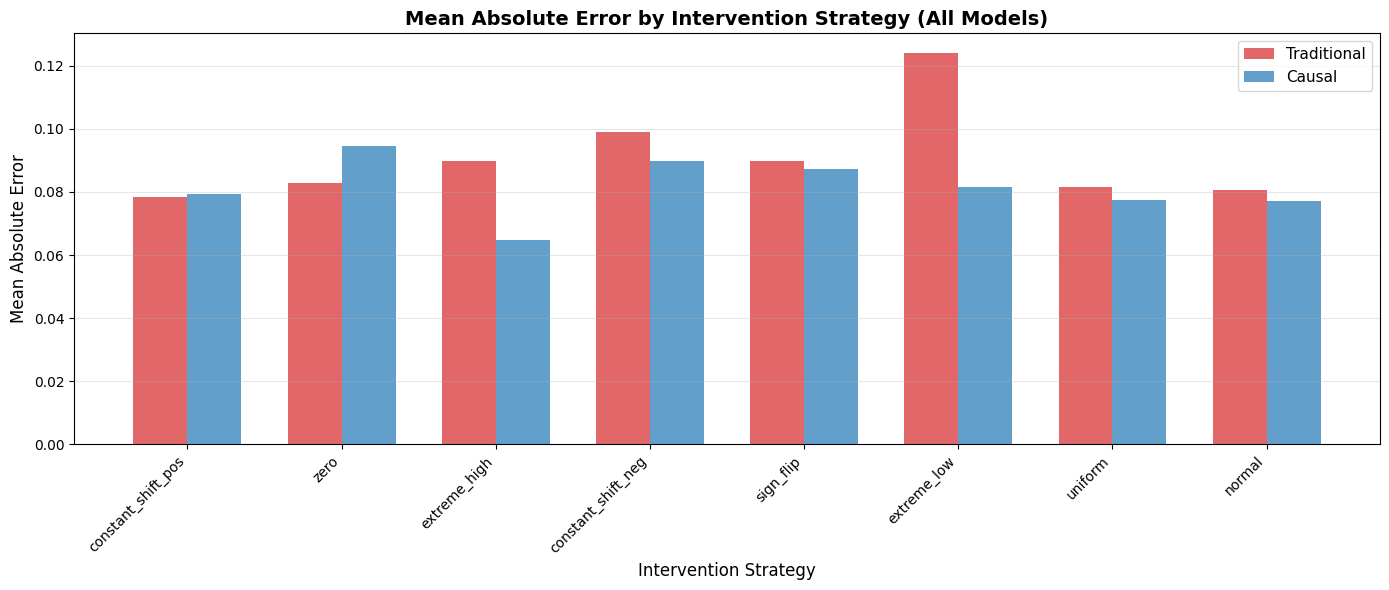

In [18]:
# ============================================================
# Grouped bar chart: Mean error by strategy (aggregated across all models)
# ============================================================
strategies = interv_df['strategy'].unique()
n_strategies = len(strategies)

strategy_means = interv_df.groupby('strategy').agg(
    trad_mae=('traditional_error', 'mean'),
    causal_mae=('causal_error', 'mean'),
).reindex(strategies).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(n_strategies)
width = 0.35

bars1 = ax.bar(x - width/2, strategy_means['trad_mae'], width, 
               label='Traditional', color='tab:red', alpha=0.7)
bars2 = ax.bar(x + width/2, strategy_means['causal_mae'], width,
               label='Causal', color='tab:blue', alpha=0.7)

ax.set_xlabel('Intervention Strategy', fontsize=12)
ax.set_ylabel('Mean Absolute Error', fontsize=12)
ax.set_title('Mean Absolute Error by Intervention Strategy (All Models)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 12d. Per-Model MAE Comparison Bar Chart

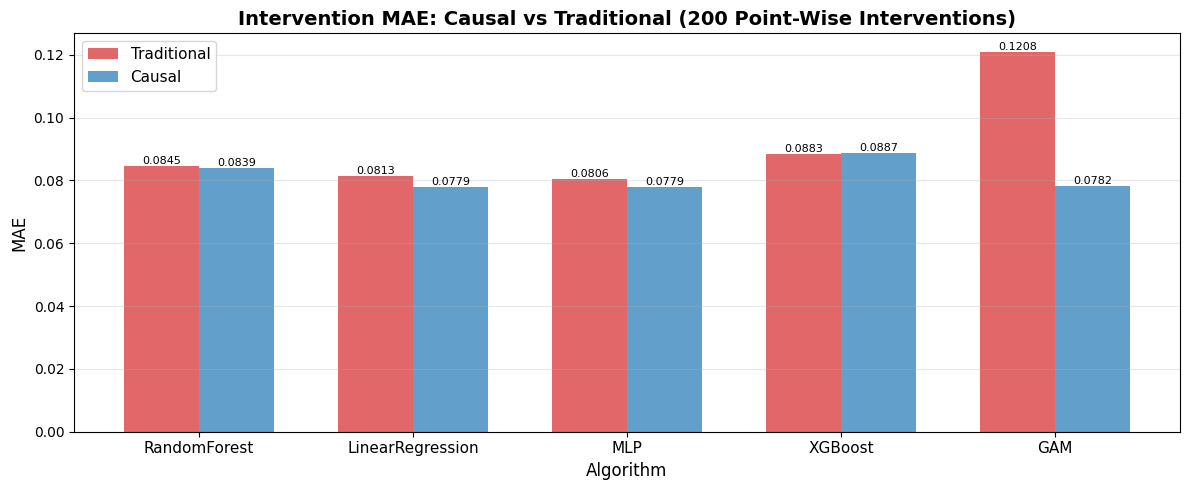


Lower MAE is better. Causal models should outperform traditional under interventions.


In [19]:
# ============================================================
# Bar chart: MAE per model (Causal vs Traditional)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))

trad_maes = agg_df[agg_df['Model_Type'] == 'Traditional'].set_index('Algorithm')['MAE']
causal_maes = agg_df[agg_df['Model_Type'] == 'Causal'].set_index('Algorithm')['MAE']

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, [trad_maes.get(m, 0) for m in model_names], width,
               label='Traditional', color='tab:red', alpha=0.7)
bars2 = ax.bar(x + width/2, [causal_maes.get(m, 0) for m in model_names], width,
               label='Causal', color='tab:blue', alpha=0.7)

ax.set_xlabel('Algorithm', fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.set_title(f'Intervention MAE: Causal vs Traditional ({N_INTERVENTIONS} Point-Wise Interventions)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\nLower MAE is better. Causal models should outperform traditional under interventions.")

### 12e. Error vs Intervention Magnitude (Delta)

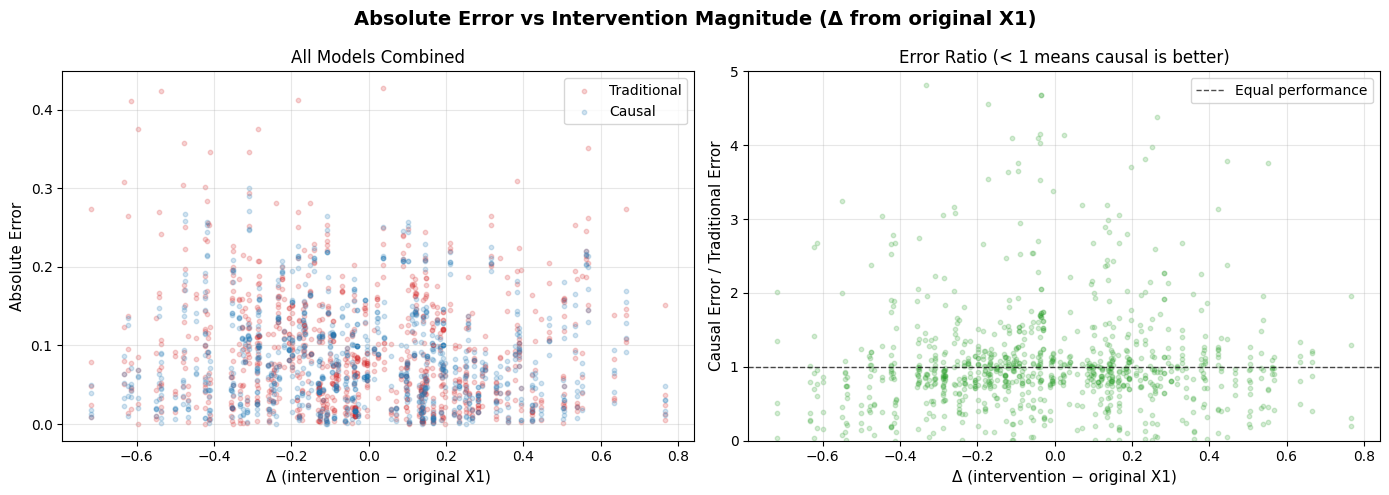


FINAL SUMMARY
Overall Traditional MAE: 0.0911
Overall Causal MAE:      0.0813
Causal Improvement:      10.7%

Causal models outperform traditional models under 200 diverse point-wise interventions.


In [20]:
# ============================================================
# Scatter: Error vs intervention delta (how far from original)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Absolute Error vs Intervention Magnitude (Δ from original X1)',
             fontsize=14, fontweight='bold')

# Aggregate across all models for clarity
ax = axes[0]
ax.scatter(interv_df['delta'], interv_df['traditional_error'], 
           alpha=0.2, s=10, color='tab:red', label='Traditional')
ax.scatter(interv_df['delta'], interv_df['causal_error'],
           alpha=0.2, s=10, color='tab:blue', label='Causal')
ax.set_xlabel('Δ (intervention − original X1)', fontsize=11)
ax.set_ylabel('Absolute Error', fontsize=11)
ax.set_title('All Models Combined', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Ratio plot: causal_error / traditional_error
ax = axes[1]
# Avoid division by zero
mask = interv_df['traditional_error'] > 1e-10
ratio = interv_df.loc[mask, 'causal_error'] / interv_df.loc[mask, 'traditional_error']
ax.scatter(interv_df.loc[mask, 'delta'], ratio, alpha=0.2, s=10, color='tab:green')
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Equal performance')
ax.set_xlabel('Δ (intervention − original X1)', fontsize=11)
ax.set_ylabel('Causal Error / Traditional Error', fontsize=11)
ax.set_title('Error Ratio (< 1 means causal is better)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, min(5, ratio.quantile(0.99)))

plt.tight_layout()
plt.show()

# Final summary
print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
overall_trad_mae = interv_df['traditional_error'].mean()
overall_causal_mae = interv_df['causal_error'].mean()
improvement = (overall_trad_mae - overall_causal_mae) / overall_trad_mae * 100
print(f"Overall Traditional MAE: {overall_trad_mae:.4f}")
print(f"Overall Causal MAE:      {overall_causal_mae:.4f}")
print(f"Causal Improvement:      {improvement:.1f}%")
print(f"\nCausal models {'outperform' if improvement > 0 else 'underperform'} traditional models "
      f"under {N_INTERVENTIONS} diverse point-wise interventions.")